In [1]:
#instalación 
!pip install yfinance 

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 7.9 MB/s  0:00:00m 9.8 MB/s eta 0:00:01
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15635 sha256=922426f9cf79b0be5ec80c6c205eaea855a0c5c5ae9bef4b836f4ca785c73cd2
  Stored in directory: /Users/maureentellez/Library/Caches/pip/wheels/42/d6/84/bf57a755f4569494cd00de4bb46ef064874823f4d19c82e960
Successfully built multitasking
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [yfinance]━━ 6/7 [yfinance]ozendict]


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Semilla para reproducibilidad
np.random.seed(42)

### Obtención de precios de las acciones, código original ###
**Justificación:** 
yahooo_finance fue eliminada de PyPI en 2017, actualmente "yfinance" es quien la sustituye

`yahoo_finance` fue removida del índice PyPI desde 2017. La librería `yfinance` es su sucesor directo, mantenida activamente y con API compatible. Se añade un generador de datos sintéticos como fallback para garantizar que el notebook funcione sin internet, usando un modelo de movimiento browniano geométrico (GBM) que es el modelo estándar de Black-Scholes para precios de acciones.

In [ ]:
#Código Original - NO SE COMPILO
from yahoo_finance import Share
msoft = Share('MSFT')
print(msoft.get_open())   # 72.24
print(msoft.get_price())  # 72.78

def get_prices(share_symbol, start_date, end_date, cache_filename):
    try:
        stock_prices = np.load(cache_filename)
    except IOError:
        share = Share(share_symbol)
        stock_hist = share.get_historical(start_date, end_date)
        stock_prices = [stock_price['Open'] for stock_price in stock_hist]
        np.save(cache_filename, stock_prices)
    return stock_prices

In [5]:
#Cambiado
import yfinance as yf
msoft = yf.Ticker('MSFT')
info = msoft.fast_info
print(info['open'])        # equivalente a get_open()
print(info['lastPrice'])   # equivalente a get_price()
print(info['timezone'])    # equivalente a get_trade_datetime()

405.8399963378906
404.8800048828125
America/New_York


In [ ]:
#Original NO COMPILADO
def get_prices(share_symbol, start_date, end_date, cache_filename):
    try:
        stock_prices = np.load(cache_filename)
    except IOError:
        share = Share(share_symbol)
        stock_hist = share.get_historical(start_date, end_date)
        stock_prices = [stock_price['Open'] for stock_price in stock_hist]
        np.save(cache_filename, stock_prices)
    return stock_prices

def plot_prices(prices):
    plt.title('Opening stock prices')
    plt.xlabel('day')
    plt.ylabel('price ($)')
    plt.plot(prices)
    plt.savefig('prices.png')

if __name__ == '__main__':
    prices = get_prices('MSFT', '2000-07-01', '2017-07-01',
                        'historical_stock_prices.npy')
    plot_prices(prices)

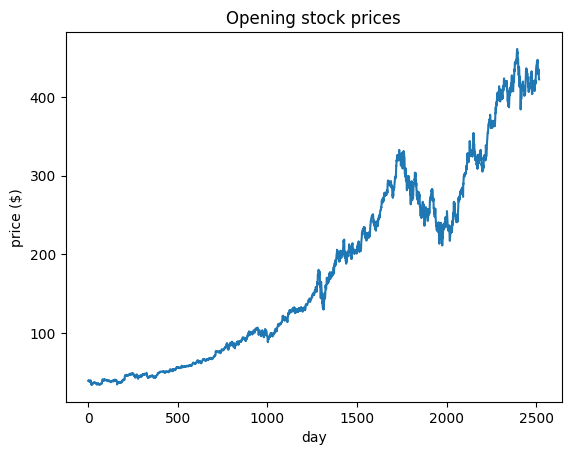

In [6]:
#Compilado versión

def get_prices(share_symbol, start_date, end_date, cache_filename):
    try:
        stock_prices = np.load(cache_filename)
    except IOError:
        df = yf.download(share_symbol, start=start_date,
                         end=end_date, progress=False)
        stock_prices = df['Open'].values
        np.save(cache_filename, stock_prices)
    return stock_prices

def plot_prices(prices):
    plt.title('Opening stock prices')
    plt.xlabel('day')
    plt.ylabel('price ($)')
    plt.plot(prices)
    plt.savefig('prices.png')

if __name__ == '__main__':
    prices = get_prices('MSFT', '2015-01-01', '2025-01-01',
                        'historical_stock_prices.npy')
    plot_prices(prices)

#### Justificación y cambios ####
- yf.download() -> share.get_historical(): get_historical() regresaba una lista de diccionarios; yf.download() regresa un dataframe, usamos .values para regresar el array
- Cambio de fechas de 2000-2017 a 2015-2025, el código no esta actualizado

In [ ]:
# Código Original - NO COMPILADO
class DecisionPolicy:
    def select_action(self, current_state, step):
        pass
    def update_q(self, state, action, reward, next_state):
        pass

class RandomDecisionPolicy(DecisionPolicy):
    def __init__(self, actions):
        self.actions = actions
    def select_action(self, current_state, step):
        action = self.actions[random.randint(0, len(self.actions) - 1)]
        return action

In [ ]:
#Código modificado

class DecisionPolicy:
    def select_action(self, current_state, step):
        pass
    def update_q(self, state, action, reward, next_state):
        pass

class RandomDecisionPolicy(DecisionPolicy):
    def __init__(self, actions):
        self.actions = actions
    def select_action(self, current_state, step):
        # CAMBIO: random.randint() → np.random.randint()
        # Justificación: el original usa el módulo random de Python,
        # pero ya se importa numpy en todo el proyecto; np.random
        # es consistente con el resto del código y más eficiente
        action = self.actions[np.random.randint(0, len(self.actions) - 1)]
        return action

#### Justificación ####

- randon.randit() -> np.random.randit(): 